# RooFit：从 PDF 到组合模型与 likelihood

能谱分析中，一个峰可能叠加在连续本底上；不同探测器测到的谱可能共享峰位，却有不同的分辨；有时需要直接拟合逐事件的能量或时间，而不是先建立 histogram。RooFit 用归一化的 probability density function（PDF）、数据集和 likelihood 来组织这些问题。

本教程从一个 Gaussian PDF 开始，依次引入数据、workspace、signal + background、extended likelihood、误差与验证。后面用多维模型和 simultaneous fit 展示同一套对象如何扩展到实际分析。建议先学习第二章参数估计，并读过 [ROOT Fit：从数据、模型到参数与误差](ROOT_Fit_Tutorial.html)。

网页顶部可以统一切换 PyROOT / ROOT C++。下载的 notebook 用 **Python 3 / PyROOT kernel** 从上到下执行，每段之后可展开对应的 C++。全部例子是显式给定模型的 toy data，不是实验数据；图与打印结果由代码直接产生。

## 1. 函数与归一化 PDF

`TF1("f","gaus",...)` 中的幅度是自由参数，函数积分一般不为 1。RooFit 的 Gaussian PDF 则表示在所选观测范围内的概率密度：

$$p(x\mid\mu,\sigma)=\frac{\exp[-(x-\mu)^2/(2\sigma^2)]}
{\int_{x_\min}^{x_\max}\exp[-(u-\mu)^2/(2\sigma^2)]du}.$$

RooFit 会随参数变化计算归一化。这里积分变量是观测量，**不是对参数积分**。`RooRealVar` 的范围因而是统计模型的一部分，不只是画图的横轴范围。

| 对象 | 在分析中的含义 |
| --- | --- |
| `RooRealVar` | 一个观测量或实数参数；可给初值、范围、单位 |
| `RooGaussian`、`RooExponential` | PDF 的组成部分 |
| `RooArgSet` / `RooArgList` | 对象集合 / 有顺序的列表；组分与系数的对应关系需要列表 |
| `RooDataSet` / `RooDataHist` | 逐事件数据 / binned 数据 |
| `RooFitResult` | 拟合状态、浮动参数、误差与协方差 |
| `RooPlot` / `RooWorkspace` | 存放曲线和数据的画框 / 管理模型及数据的容器 |

常规 ROOT Fit 同样能做 likelihood 拟合，RooFit 也支持 least squares。选择 RooFit 的理由是概率模型与数据组织更方便，而不是换了一个“更高级”的统计方法。

### 1.1 运行环境

`RF` 只是 `ROOT.RooFit` 的短写。`Save()` 返回拟合结果，`PrintLevel(-1)` 减少 minimizer 的迭代输出。这里关闭 RooFit 的信息性日志，仍保留 warning 和 error，并主动输出关键参数和状态。

In [1]:
import math
from array import array
from pathlib import Path
from IPython.display import display, Image
import ROOT

RF = ROOT.RooFit
ROOT.gROOT.SetBatch(True)
ROOT.gStyle.SetOptStat(0)
ROOT.gErrorIgnoreLevel = ROOT.kWarning  # 只去掉图片保存等信息性提示
ROOT.RooMsgService.instance().setGlobalKillBelow(RF.WARNING)
ROOT.RooRandom.randomGenerator().SetSeed(20260910)
Path("fit_figures").mkdir(exist_ok=True)
print("ROOT", ROOT.gROOT.GetVersion())

ROOT 6.40.02


<details><summary>ROOT C++ 对应代码</summary>

```cpp
#include <RooGlobalFunc.h>
using namespace RooFit;

gROOT->SetBatch(true);
gStyle->SetOptStat(0);
gErrorIgnoreLevel = kWarning;  // 只去掉图片保存等信息性提示
RooMsgService::instance().setGlobalKillBelow(RooFit::WARNING);
RooRandom::randomGenerator()->SetSeed(20260910);
gSystem->mkdir("fit_figures", true);
std::cout << std::fixed << std::setprecision(4);
std::cout << "ROOT " << gROOT->GetVersion() << std::endl;
```

</details>

### 1.2 建立 Gaussian 模型

`x` 是观测量，$\mu$ 和 $\sigma$ 是待估参数。`RooRealVar("mean",...,0.4,-2,2)` 的后三个数依次是初值、下限、上限。只给一个数的构造通常表示常数；希望参数参与拟合时，明确给出范围。

In [2]:
x = ROOT.RooRealVar("x", "x", -5, 5)
mean = ROOT.RooRealVar("mean", "mean", 0.4, -2, 2)
sigma = ROOT.RooRealVar("sigma", "sigma", 0.7, 0.1, 3)
gauss = ROOT.RooGaussian("gauss", "Gaussian PDF", x, mean, sigma)
obs = ROOT.RooArgSet(x)
gauss_data = gauss.generate(obs, 1000)
print("Number of events =", gauss_data.numEntries())

Number of events = 1000


<details><summary>ROOT C++ 对应代码</summary>

```cpp
RooRealVar x("x", "x", -5, 5);
RooRealVar mean("mean", "mean", 0.4, -2, 2);
RooRealVar sigma("sigma", "sigma", 0.7, 0.1, 3);
RooGaussian gauss("gauss", "Gaussian PDF", x, mean, sigma);
RooArgSet obs(x);
auto gauss_data = gauss.generate(obs, 1000);
std::cout << "Number of events = " << gauss_data->numEntries() << std::endl;
```

</details>

`generate` 抽样得到 `RooDataSet`，每一行保留一个事件的 $x$。这里固定样本数为 1000，只研究分布形状。Gaussian 的宽度由模型定义，并不是拟合参数误差。

## 2. 第一次 unbinned fit

对独立观测 $x_i$，unbinned likelihood 是

$$L(\boldsymbol\theta)=\prod_{i=1}^{N}p(x_i\mid\boldsymbol\theta).$$

`fitTo` 最小化 $-\log L$。先把参数改成与生成值不同的合理初值，再拟合，避免把生成参数原封不动当成拟合结果。`setVal` 改当前值，`setConstant(True)` 才会固定参数。

In [3]:
mean.setVal(0)
sigma.setVal(1)
gauss_result = gauss.fitTo(gauss_data, RF.Save(), RF.PrintLevel(-1))
print("status =", gauss_result.status(), "covQual =", gauss_result.covQual())
print(f"mean  = {mean.getVal():.4f} +/- {mean.getError():.4f}")
print(f"sigma = {sigma.getVal():.4f} +/- {sigma.getError():.4f}")

status = 0 covQual = 3
mean  = 0.4209 +/- 0.0221
sigma = 0.6986 +/- 0.0156


<details><summary>ROOT C++ 对应代码</summary>

```cpp
mean.setVal(0);
sigma.setVal(1);
auto gauss_result = gauss.fitTo(*gauss_data, Save(), PrintLevel(-1));
std::cout << "status = " << gauss_result->status() << " covQual = " << gauss_result->covQual() << std::endl;
std::cout << "mean  = " << mean.getVal() << " +/- " << mean.getError() << std::endl;
std::cout << "sigma = " << sigma.getVal() << " +/- " << sigma.getError() << std::endl;
```

</details>

### 2.1 先画数据，再叠加模型

`x.frame()` 创建 `RooPlot`。先 `data.plotOn`，再 `pdf.plotOn`，模型曲线就按图中数据的事件数缩放。图上的 bins 用于显示；这次拟合仍使用每个事件的 $x$。

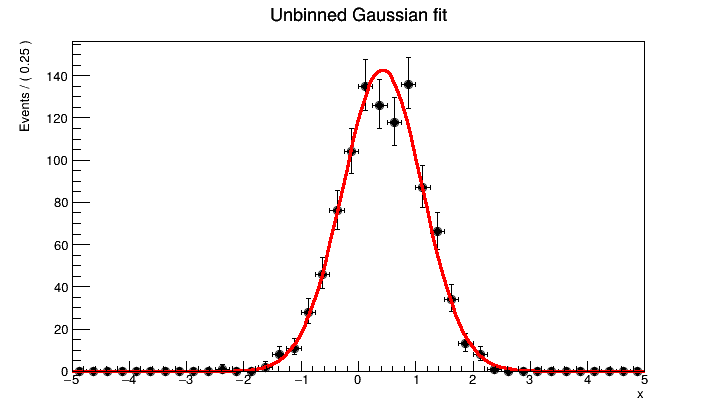

In [4]:
frame = x.frame(RF.Title("Unbinned Gaussian fit"))
gauss_data.plotOn(frame, RF.Binning(40), RF.Name("observed"))
gauss.plotOn(frame, RF.Name("fitted"), RF.LineColor(ROOT.kRed))
c = ROOT.TCanvas("c_roo_gauss", "Gaussian PDF and data", 720, 440)
frame.Draw()
c.SaveAs("fit_figures/roofit-gaussian.png")
display(Image(filename="fit_figures/roofit-gaussian.png"))

<details><summary>ROOT C++ 对应代码</summary>

```cpp
auto frame = x.frame(Title("Unbinned Gaussian fit"));
gauss_data->plotOn(frame, Binning(40), Name("observed"));
gauss.plotOn(frame, Name("fitted"), LineColor(kRed));
auto c = new TCanvas("c_roo_gauss", "Gaussian PDF and data", 720, 440);
frame->Draw();
c->SaveAs("fit_figures/roofit-gaussian.png");
```

</details>

### 2.2 Residual 与显示用的 pull

`residHist("observed","fitted")` 计算数据减曲线；`pullHist` 再除以图中数据点对应的误差。给数据和曲线起名字，避免添加组分曲线后误把最后画的本底当成总模型。下面画的是**显示用的 pull**，并不是对每个原始事件定义的残差。

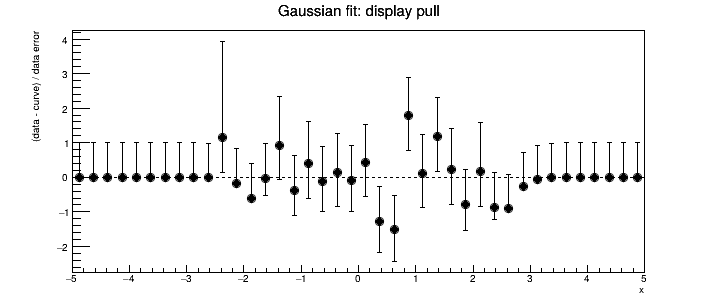

In [5]:
gauss_pull = frame.pullHist("observed", "fitted")
pull_frame = x.frame(RF.Title("Gaussian fit: display pull"))
pull_frame.addPlotable(gauss_pull, "P")
pull_frame.GetYaxis().SetTitle("(data - curve) / data error")
c = ROOT.TCanvas("c_roo_gauss_pull", "Gaussian pull", 720, 330)
pull_frame.Draw()
zero_gauss = ROOT.TLine(-5, 0, 5, 0)
zero_gauss.SetLineStyle(2)
zero_gauss.Draw()
c.SaveAs("fit_figures/roofit-gaussian-pull.png")
display(Image(filename="fit_figures/roofit-gaussian-pull.png"))

<details><summary>ROOT C++ 对应代码</summary>

```cpp
auto gauss_pull = frame->pullHist("observed", "fitted");
auto pull_frame = x.frame(Title("Gaussian fit: display pull"));
pull_frame->addPlotable(gauss_pull, "P");
pull_frame->GetYaxis()->SetTitle("(data - curve) / data error");
c = new TCanvas("c_roo_gauss_pull", "Gaussian pull", 720, 330);
pull_frame->Draw();
auto zero_gauss = new TLine(-5, 0, 5, 0);
zero_gauss->SetLineStyle(2);
zero_gauss->Draw();
c->SaveAs("fit_figures/roofit-gaussian-pull.png");
```

</details>

`status()==0` 表示 minimizer 报告成功，`covQual()==3` 表示协方差质量被认为准确；它们不检验 Gaussian 是否为正确的物理模型。`RooPlot::chiSquare` 可给图上曲线的 $\chi^2/\mathrm{ndf}$，但它依赖显示 bins 与误差条，不是 unbinned likelihood 自身的 goodness-of-fit，更不能只凭该数认定模型成立。接口见 [rf109：residual 与 pull](https://root.cern.ch/doc/master/rf109__chi2residpull_8py.html)。

## 3. 从 TTree 或 TH1 导入数据

在实验中，观测值常存在 TTree 中。RooFit 导入时按变量名匹配 branch，并只接受变量允许范围内的数据，所以要核对导入前后的事例数。下面先用刚才的样本构造一个小 TTree，随后演示导入；实际分析可把它替换为从 ROOT 文件读取的 TTree。

In [6]:
tree = ROOT.TTree("events", "Gaussian toy events")
value = array("d", [0])
tree.Branch("x", value, "x/D")
h_import = ROOT.TH1D("h_import", ";x;counts / bin", 40, -5, 5)
for i in range(gauss_data.numEntries()):
    value[0] = gauss_data.get(i).getRealValue("x")
    tree.Fill()
    h_import.Fill(value[0])
from_tree = ROOT.RooDataSet("from_tree", "imported events", obs, RF.Import(tree))
from_hist = ROOT.RooDataHist("from_hist", "imported counts", ROOT.RooArgList(x), RF.Import(h_import))
print("TTree entries:", tree.GetEntries(), "RooDataSet entries:", from_tree.numEntries())
print("TH1 counts:", h_import.Integral(), "RooDataHist counts:", from_hist.sumEntries())

TTree entries: 1000 RooDataSet entries: 1000
TH1 counts: 1000.0 RooDataHist counts: 1000.0


<details><summary>ROOT C++ 对应代码</summary>

```cpp
TTree tree("events", "Gaussian toy events");
double value = 0;
tree.Branch("x", &value, "x/D");
TH1D h_import("h_import", ";x;counts / bin", 40, -5, 5);
for (int i = 0; i < gauss_data->numEntries(); ++i) {
    value = gauss_data->get(i)->getRealValue("x");
    tree.Fill();
    h_import.Fill(value);
}
RooDataSet from_tree("from_tree", "imported events", obs, Import(tree));
RooDataHist from_hist("from_hist", "imported counts", RooArgList(x), Import(h_import));
std::cout << "TTree entries: " << tree.GetEntries() << " RooDataSet entries: " << from_tree.numEntries() << std::endl;
std::cout << "TH1 counts: " << h_import.Integral() << " RooDataHist counts: " << from_hist.sumEntries() << std::endl;
```

</details>

`RooDataHist::numEntries()` 数的是储存的 bin 条目；计数总和要用 `sumEntries()`。Histogram 不再保留每个事件在 bin 内的具体位置，不能把 bin 中心复制若干次当成原来的 unbinned 数据。

<a id="signal-background"></a>
## 4. RooWorkspace 与组合模型

### 4.1 用 workspace 管理对象

`RooWorkspace` 保存变量、PDF 和数据，并维护它们之间的依赖。`factory` 是构造对象的简写，不改变模型的统计含义。先看懂上一节显式创建对象的方式，再使用它可减少重复代码。

- `x[-5,5]`：创建范围为 $[-5,5]$ 的变量。
- `mu[0.4,-2,2]`：创建初值 0.4、范围 $[-2,2]$ 的浮动参数。
- `mu[0.4]`：创建初始为常量的参数。
- `Gaussian::sig(x,mu,s)`：调用 `RooGaussian`，对象名为 `sig`。

本节的 $x$ 可理解为相对于参考峰位的能量偏移，单位 keV。模型包含 Gaussian 信号和在此有限区间内的指数本底。这个指数只是教学用的平滑本底模型，不用于概括所有 gamma 能谱本底。

In [7]:
w = ROOT.RooWorkspace("w", "signal and background")
w.factory("Gaussian::sig(x[-5,5],mu[0.4,-2,2],s[0.7,0.1,2])")
w.factory("Exponential::bkg(x,k[-0.15,-1,0])")
w.factory("SUM::model(ns[300,0,2000]*sig,nb[700,0,3000]*bkg)")
xx = w.var("x")
xx.setUnit("keV")
model = w.pdf("model")
ns, nb = w.var("ns"), w.var("nb")
model.Print("t")  # 显示组分及参数之间的关系

0x84ff92300 RooAddPdf::model = 0.95481/1 [Auto,Clean] 
  0x845680600/V- RooGaussian::sig = 0.849366 [Auto,Dirty] 
    0x852608800/V- RooRealVar::x = 0
    0x852608c00/V- RooRealVar::mu = 0.4
    0x852609000/V- RooRealVar::s = 0.7
  0x852609c00/V- RooRealVar::ns = 300
  0x852300a00/V- RooExponential::bkg = 1 [Auto,Dirty] 
    0x852608800/V- RooRealVar::x = 0
    0x852608000/V- RooRealVar::k = -0.15
  0x85260a000/V- RooRealVar::nb = 700


<details><summary>ROOT C++ 对应代码</summary>

```cpp
RooWorkspace w("w", "signal and background");
w.factory("Gaussian::sig(x[-5,5],mu[0.4,-2,2],s[0.7,0.1,2])");
w.factory("Exponential::bkg(x,k[-0.15,-1,0])");
w.factory("SUM::model(ns[300,0,2000]*sig,nb[700,0,3000]*bkg)");
auto xx = w.var("x");
xx->setUnit("keV");
auto model = w.pdf("model");
auto ns = w.var("ns");
auto nb = w.var("nb");
model->Print("t");  // 显示组分及参数之间的关系
```

</details>

### 4.2 Fraction 与 yield 是两种不同参数化

两个归一化组分可写成

$$p(x)=f_s\,p_s(x)+(1-f_s)\,p_b(x),\qquad 0\le f_s\le1.$$

这里的 $f_s$ 是信号比例。相应 factory 表达式为 `SUM::shape(frac*sig,bkg)`：两个 PDF 只给一个系数，剩余比例是 $1-\text{frac}$。

上一段的 `SUM::model(ns*sig,nb*bkg)` 则对两个 PDF 都给出系数。此时 `ns`、`nb` 是观测范围内的**期望产额**，模型可用于 extended likelihood：

$$L_\mathrm{ext}=\frac{e^{-(N_s+N_b)}}{N!}
\prod_{i=1}^{N}[N_s p_s(x_i)+N_b p_b(x_i)].$$

总事件数的 Poisson 涨落也参与估计。比例与产额不能混用；尤其不要把归一化 PDF 的峰高当成计数。

下面从期望 $N_s=300$、$N_b=700$ 的模型抽取一次实验，**总数也按 Poisson 涨落**。然后用同一份数据先拟合比例，再拟合产额。

In [8]:
data = model.generate(ROOT.RooArgSet(xx), RF.Extended())
data.SetName("spectrum_data")
w.factory("SUM::shape(frac[0.3,0,1]*sig,bkg)")
shape = w.pdf("shape")
w.var("mu").setVal(0)
w.var("s").setVal(1)
shape_result = shape.fitTo(data, RF.Save(), RF.Extended(False), RF.PrintLevel(-1))
fraction = w.var("frac")
print("Observed events =", data.numEntries())
print("Shape-only status =", shape_result.status())
print(f"Signal fraction = {fraction.getVal():.4f} +/- {fraction.getError():.4f}")
print(f"Conditional signal count = {data.numEntries()*fraction.getVal():.2f} +/- {data.numEntries()*fraction.getError():.2f}")

Observed events = 1045
Shape-only status = 0
Signal fraction = 0.3179 +/- 0.0238
Conditional signal count = 332.20 +/- 24.85


<details><summary>ROOT C++ 对应代码</summary>

```cpp
auto data = model->generate(RooArgSet(*xx), Extended());
data->SetName("spectrum_data");
w.factory("SUM::shape(frac[0.3,0,1]*sig,bkg)");
auto shape = w.pdf("shape");
w.var("mu")->setVal(0);
w.var("s")->setVal(1);
auto shape_result = shape->fitTo(*data, Save(), Extended(false), PrintLevel(-1));
auto fraction = w.var("frac");
std::cout << "Observed events = " << data->numEntries() << std::endl;
std::cout << "Shape-only status = " << shape_result->status() << std::endl;
std::cout << "Signal fraction = " << fraction->getVal() << " +/- " << fraction->getError() << std::endl;
std::cout << "Conditional signal count = " << data->numEntries()*fraction->getVal()
          << " +/- " << data->numEntries()*fraction->getError() << std::endl;
```

</details>

这里的 conditional signal count 误差以观测总数固定为条件。下面 extended fit 的产额误差包含总数的 Poisson 信息，二者不是同一误差问题。对自由总产额的这个模型，两种方法给出的信号比例与峰形应接近，但不能要求产额误差也相同。

### 4.3 Extended unbinned fit

In [9]:
ns.setVal(280)
nb.setVal(720)
result = model.fitTo(data, RF.Save(), RF.Extended(), RF.PrintLevel(-1))
print("status =", result.status(), "covQual =", result.covQual(), "EDM =", result.edm())
for name in ("mu", "s", "k", "ns", "nb"):
    par = w.var(name)
    print(f"{name:2s} = {par.getVal():.4f} +/- {par.getError():.4f}")
print(f"Expected total = {ns.getVal()+nb.getVal():.3f}")
w.saveSnapshot("unbinned_fit", w.allVars())

status = 0 covQual = 3 EDM = 0.00020963718841494842
mu = 0.4840 +/- 0.0569
s  = 0.6993 +/- 0.0525
k  = -0.1601 +/- 0.0155
ns = 332.2718 +/- 26.8839
nb = 712.5564 +/- 33.2061
Expected total = 1044.828


True

<details><summary>ROOT C++ 对应代码</summary>

```cpp
ns->setVal(280);
nb->setVal(720);
auto result = model->fitTo(*data, Save(), Extended(), PrintLevel(-1));
std::cout << "status = " << result->status() << " covQual = " << result->covQual() << " EDM = " << result->edm() << std::endl;
for (const char* name : {"mu", "s", "k", "ns", "nb"}) {
    auto par = w.var(name);
    std::cout << name << " = " << par->getVal() << " +/- " << par->getError() << std::endl;
}
std::cout << "Expected total = " << ns->getVal()+nb->getVal() << std::endl;
w.saveSnapshot("unbinned_fit", w.allVars());
```

</details>

`saveSnapshot` 保存当前参数值，后面的 binned 比较、likelihood scan 会改变变量，可以用 `loadSnapshot` 恢复。`RooFitResult` 保存的是拟合摘要，不会在每次画图时自动把模型变量恢复成那一次拟合值。

### 4.4 完整模型、本底、信号与 residual

用 `model.plotOn(...,Components("bkg"))` 从**总模型中**画出本底，才能保持对应产额的归一化。直接单独画 `bkg` 时，它可能被缩放到整份数据的事件数，造成看似“本底完全偏离”的图。

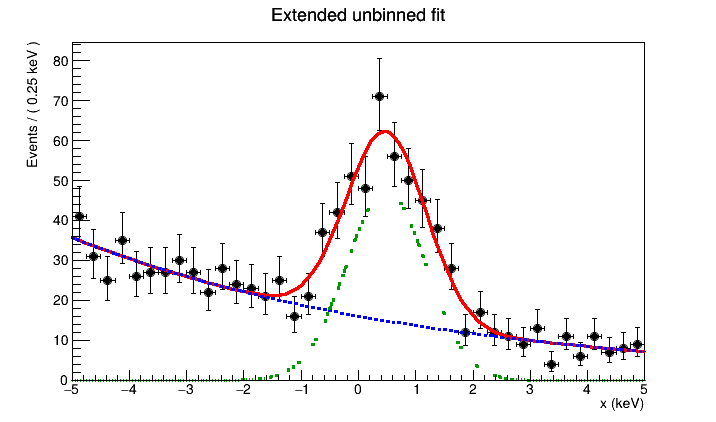

In [10]:
sb_frame = xx.frame(RF.Title("Extended unbinned fit"))
data.plotOn(sb_frame, RF.Binning(40), RF.Name("sb_data"))
model.plotOn(sb_frame, RF.Name("sb_total"), RF.LineColor(ROOT.kRed))
model.plotOn(sb_frame, RF.Components("bkg"), RF.LineColor(ROOT.kBlue), RF.LineStyle(2))
model.plotOn(sb_frame, RF.Components("sig"), RF.LineColor(ROOT.kGreen+2), RF.LineStyle(3))
c = ROOT.TCanvas("c_roo_sb", "Signal plus background", 720, 450)
sb_frame.Draw()
c.SaveAs("fit_figures/roofit-signal-background.png")
display(Image(filename="fit_figures/roofit-signal-background.png"))

<details><summary>ROOT C++ 对应代码</summary>

```cpp
auto sb_frame = xx->frame(Title("Extended unbinned fit"));
data->plotOn(sb_frame, Binning(40), Name("sb_data"));
model->plotOn(sb_frame, Name("sb_total"), LineColor(kRed));
model->plotOn(sb_frame, Components("bkg"), LineColor(kBlue), LineStyle(2));
model->plotOn(sb_frame, Components("sig"), LineColor(kGreen+2), LineStyle(3));
c = new TCanvas("c_roo_sb", "Signal plus background", 720, 450);
sb_frame->Draw();
c->SaveAs("fit_figures/roofit-signal-background.png");
```

</details>

红实线是总模型，蓝虚线是指数本底，绿点线是 Gaussian 信号。下面的 raw residual 保留 counts/bin 的单位。

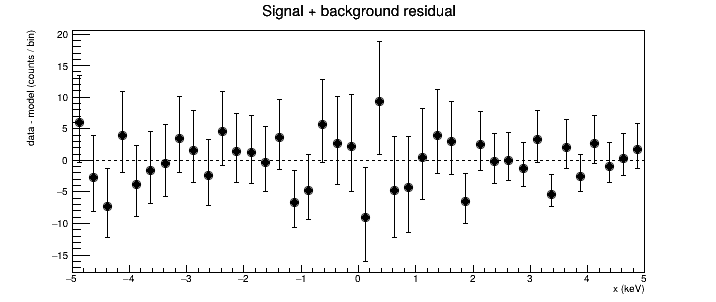

In [11]:
sb_residual = sb_frame.residHist("sb_data", "sb_total")
sb_res_frame = xx.frame(RF.Title("Signal + background residual"))
sb_res_frame.addPlotable(sb_residual, "P")
sb_res_frame.GetYaxis().SetTitle("data - model (counts / bin)")
c = ROOT.TCanvas("c_roo_sb_res", "Signal background residual", 720, 330)
sb_res_frame.Draw()
zero_sb = ROOT.TLine(-5, 0, 5, 0)
zero_sb.SetLineStyle(2)
zero_sb.Draw()
c.SaveAs("fit_figures/roofit-signal-background-residual.png")
display(Image(filename="fit_figures/roofit-signal-background-residual.png"))

<details><summary>ROOT C++ 对应代码</summary>

```cpp
auto sb_residual = sb_frame->residHist("sb_data", "sb_total");
auto sb_res_frame = xx->frame(Title("Signal + background residual"));
sb_res_frame->addPlotable(sb_residual, "P");
sb_res_frame->GetYaxis()->SetTitle("data - model (counts / bin)");
c = new TCanvas("c_roo_sb_res", "Signal background residual", 720, 330);
sb_res_frame->Draw();
auto zero_sb = new TLine(-5, 0, 5, 0);
zero_sb->SetLineStyle(2);
zero_sb->Draw();
c->SaveAs("fit_figures/roofit-signal-background-residual.png");
```

</details>

组合系数与 extended likelihood 的标准用法见 [rf202](https://root.cern.ch/doc/master/rf202__extendedmlfit_8py.html)。对于多个重叠峰，可以在 `RooAddPdf` 中增加峰分量：每个峰的净强度就是它的产额参数，误差由联合拟合给出。重叠越严重，峰产额间的相关性往往越重要；峰强度之和、比值等派生量要传播完整协方差。

<a id="binned"></a>
## 5. 同一份数据：binned 与 unbinned

固定 bin 边界后，每个 bin 的期望计数为

$$\mu_j=N_s\int_j p_s(x)dx+N_b\int_j p_b(x)dx,$$

extended binned likelihood 为 $\prod_j\operatorname{Poisson}(n_j\mid\mu_j)$。若总数固定而只拟合形状，则对应 multinomial likelihood，参数相关部分是 $\prod_j p_j^{n_j}$。**Binned/unbinned** 区分数据表示；**extended/non-extended** 区分是否拟合总产额，这是两件不同的事。

下面用同一个 `data` 建立 20 个 bins 的 `RooDataHist`，不是重新抽样。`IntegrateBins(1e-6)` 要求对连续 PDF 在各 bin 内积分，以免把较宽 bin 的中心值当作 bin 内平均值；数值是积分精度要求，不是 bin 宽度。这不恢复已经丢失的 bin 内事件位置。[rf614](https://root.cern.ch/doc/master/rf614__binned__fit__problems_8py.html)演示了该问题。

Unbinned events = 1045 ; binned total = 1045.0
Binned status = 0 covQual = 3
mu: unbinned 0.4840 +/- 0.0569; binned 0.4615 +/- 0.0602
s: unbinned 0.6993 +/- 0.0525; binned 0.7098 +/- 0.0587
ns: unbinned 332.2718 +/- 26.8839; binned 330.2694 +/- 27.6352
nb: unbinned 712.5564 +/- 33.2061; binned 715.0086 +/- 33.8824


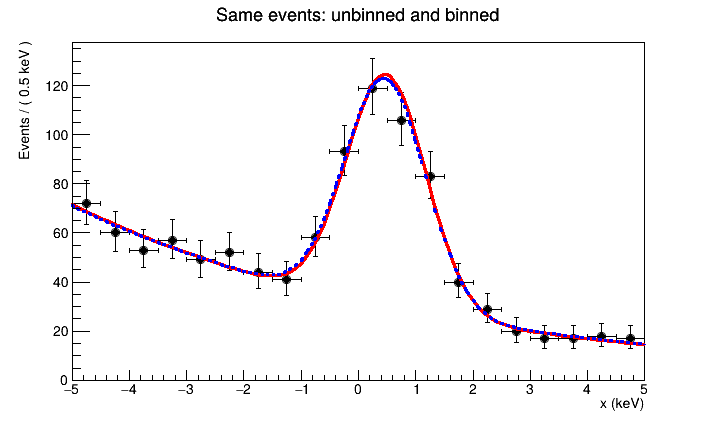

In [12]:
compare = xx.frame(RF.Title("Same events: unbinned and binned"))
data.plotOn(compare, RF.Binning(20))
model.plotOn(compare, RF.LineColor(ROOT.kRed))
xx.setBins(20)
binned = ROOT.RooDataHist("binned", "same events in bins", ROOT.RooArgSet(xx), data)
binned_result = model.fitTo(binned, RF.Save(), RF.Extended(), RF.IntegrateBins(1e-6), RF.PrintLevel(-1))
print("Unbinned events =", data.numEntries(), "; binned total =", binned.sumEntries())
print("Binned status =", binned_result.status(), "covQual =", binned_result.covQual())
for name in ("mu", "s", "ns", "nb"):
    pu = result.floatParsFinal().find(name)
    pb = w.var(name)
    print(f"{name}: unbinned {pu.getVal():.4f} +/- {pu.getError():.4f}; binned {pb.getVal():.4f} +/- {pb.getError():.4f}")
model.plotOn(compare, RF.LineColor(ROOT.kBlue), RF.LineStyle(2))
c = ROOT.TCanvas("c_roo_compare", "Binned and unbinned", 720, 450)
compare.Draw()
w.loadSnapshot("unbinned_fit")
c.SaveAs("fit_figures/roofit-binned-comparison.png")
display(Image(filename="fit_figures/roofit-binned-comparison.png"))

<details><summary>ROOT C++ 对应代码</summary>

```cpp
auto compare = xx->frame(Title("Same events: unbinned and binned"));
data->plotOn(compare, Binning(20));
model->plotOn(compare, LineColor(kRed));
xx->setBins(20);
RooDataHist binned("binned", "same events in bins", RooArgSet(*xx), *data);
auto binned_result = model->fitTo(binned, Save(), Extended(), IntegrateBins(1e-6), PrintLevel(-1));
std::cout << "Unbinned events = " << data->numEntries() << "; binned total = " << binned.sumEntries() << std::endl;
std::cout << "Binned status = " << binned_result->status() << " covQual = " << binned_result->covQual() << std::endl;
for (const char* name : {"mu", "s", "ns", "nb"}) {
    auto pu = static_cast<const RooRealVar*>(result->floatParsFinal().find(name));
    auto pb = w.var(name);
    std::cout << name << ": unbinned " << pu->getVal() << " +/- " << pu->getError()
              << "; binned " << pb->getVal() << " +/- " << pb->getError() << std::endl;
}
model->plotOn(compare, LineColor(kBlue), LineStyle(2));
c = new TCanvas("c_roo_compare", "Binned and unbinned", 720, 450);
compare->Draw();
w.loadSnapshot("unbinned_fit");
c->SaveAs("fit_figures/roofit-binned-comparison.png");
```

</details>

红实线为 unbinned fit，蓝虚线为 binned fit。两者使用同样的事件、模型和观察范围；区别仅在拟合是否使用 bin 内的事件位置。Binned fit 在数据量很大时通常更快，已有 histogram 时也只能使用其现存的信息；unbinned fit 不会自动消除模型误差或采集偏差。

## 6. 产额、积分与派生量的误差

`ns.getError()` 已是联合拟合给出的信号产额误差，它包含其他自由参数带来的相关影响，不需要再加一次同一拟合的本底误差。但对派生量 $g(\boldsymbol\theta)$，仍需使用完整协方差：

$$\sigma_g^2=\boldsymbol J C\boldsymbol J^T,\qquad J_j=\frac{\partial g}{\partial\theta_j}.$$

### 6.1 固定能量区间内的信号数

设固定 ROI 为 $[-0.5,1.5]$ keV，信号数为

$$N_{s,\mathrm{ROI}}=N_s\,F_s,\qquad F_s=\int_{\mathrm{ROI}}p_s(x)dx.$$

$F_s$ 随峰位与宽度变化，因此误差不能简单写成 $F_s\sigma_{N_s}$。`createIntegral` 建立依赖这些参数的积分对象，`RooFormulaVar` 再把产额与积分联系起来，`getPropagatedError(result)` 沿依赖关系传播参数协方差。

In [13]:
xx.setRange("roi", -0.5, 1.5)
signal_fraction = w.pdf("sig").createIntegral(ROOT.RooArgSet(xx), RF.NormSet(ROOT.RooArgSet(xx)), RF.Range("roi"))
signal_roi = ROOT.RooFormulaVar("signal_roi", "@0*@1", ROOT.RooArgList(ns, signal_fraction))
print(f"Signal fraction in ROI = {signal_fraction.getVal():.4f}")
print(f"Signal in ROI = {signal_roi.getVal():.3f} +/- {signal_roi.getPropagatedError(result):.3f}")
print(f"corr(ns,nb) = {result.correlation('ns','nb'):.4f}")

Signal fraction in ROI = 0.8472
Signal in ROI = 281.499 +/- 20.735
corr(ns,nb) = -0.4374


<details><summary>ROOT C++ 对应代码</summary>

```cpp
xx->setRange("roi", -0.5, 1.5);
auto signal_fraction = w.pdf("sig")->createIntegral(RooArgSet(*xx), NormSet(RooArgSet(*xx)), Range("roi"));
RooFormulaVar signal_roi("signal_roi", "@0*@1", RooArgList(*ns, *signal_fraction));
std::cout << "Signal fraction in ROI = " << signal_fraction->getVal() << std::endl;
std::cout << "Signal in ROI = " << signal_roi.getVal() << " +/- " << signal_roi.getPropagatedError(*result) << std::endl;
std::cout << "corr(ns,nb) = " << result->correlation("ns", "nb") << std::endl;
```

</details>

`NormSet` 指定相对于哪个观测量归一化，`Range("roi")` 只规定积分区域，不改变前面拟合的数据。此结果是在 $[-5,5]$ keV 中定义的信号产额乘以 ROI 比例。真正改变**拟合范围**时，要同时明确 PDF 归一化和 yield 所对应的区域，不能只缩短绘图横轴后重新解释 `ns`。[局部范围的 extended fit 示例](https://root.cern.ch/doc/master/rf204b__extendedLikelihood__rangedFit_8C.html)介绍 `Range`、`NormRange` 与 `fixCoefRange` 的配合。

### 6.2 拟合曲线的不确定度

`VisualizeError` 用 `RooFitResult` 的参数误差与相关性画出模型曲线的不确定度带。`RelativeExpected` 使曲线按模型的期望总产额归一化，因此带中也包含产额的不确定度；若固定按观测总数缩放，只能看到形状的不确定度。这个带不是新一批计数数据的涨落范围，图上的数据误差条是另一种不确定度。

[#0] WARNING:InputArguments -- RooAbsReal::plotOn(model) WARNING: argument CurveNameSuffix is duplicated
[#0] WARNING:InputArguments -- RooAbsReal::plotOn(model) WARNING: argument CurveNameSuffix is duplicated
[#0] WARNING:InputArguments -- RooAbsReal::plotOn(model) WARNING: argument CurveNameSuffix is duplicated
[#0] WARNING:InputArguments -- RooAbsReal::plotOn(model) WARNING: argument CurveNameSuffix is duplicated
[#0] WARNING:InputArguments -- RooAbsReal::plotOn(model) WARNING: argument CurveNameSuffix is duplicated
[#0] WARNING:InputArguments -- RooAbsReal::plotOn(model) WARNING: argument CurveNameSuffix is duplicated
[#0] WARNING:InputArguments -- RooAbsReal::plotOn(model) WARNING: argument CurveNameSuffix is duplicated
[#0] WARNING:InputArguments -- RooAbsReal::plotOn(model) WARNING: argument CurveNameSuffix is duplicated
[#0] WARNING:InputArguments -- RooAbsReal::plotOn(model) WARNING: argument CurveNameSuffix is duplicated
[#0] WARNING:InputArguments -- RooAbsReal::plotOn(model

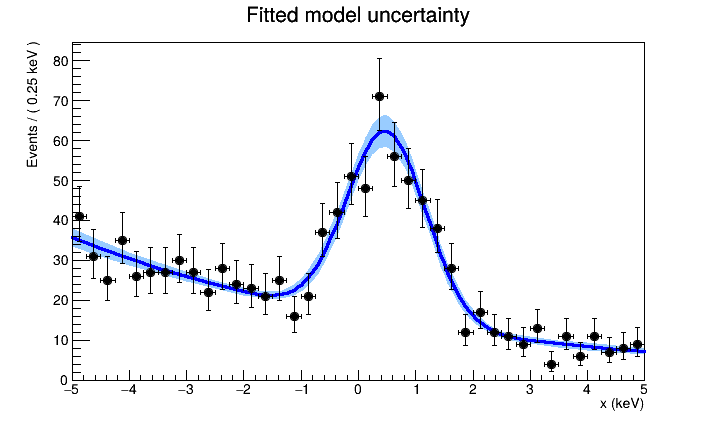

In [14]:
error_frame = xx.frame(RF.Title("Fitted model uncertainty"))
data.plotOn(error_frame, RF.Binning(40))
model.plotOn(error_frame, RF.VisualizeError(result, 1), RF.Normalization(1, ROOT.RooAbsReal.RelativeExpected), RF.FillColor(ROOT.kAzure-9))
model.plotOn(error_frame, RF.Normalization(1, ROOT.RooAbsReal.RelativeExpected), RF.LineColor(ROOT.kBlue))
data.plotOn(error_frame, RF.Binning(40))
c = ROOT.TCanvas("c_roo_band", "Model uncertainty", 720, 450)
error_frame.Draw()
c.SaveAs("fit_figures/roofit-model-band.png")
display(Image(filename="fit_figures/roofit-model-band.png"))

<details><summary>ROOT C++ 对应代码</summary>

```cpp
auto error_frame = xx->frame(Title("Fitted model uncertainty"));
data->plotOn(error_frame, Binning(40));
model->plotOn(error_frame, VisualizeError(*result, 1), Normalization(1, RooAbsReal::RelativeExpected), FillColor(kAzure-9));
model->plotOn(error_frame, Normalization(1, RooAbsReal::RelativeExpected), LineColor(kBlue));
data->plotOn(error_frame, Binning(40));
c = new TCanvas("c_roo_band", "Model uncertainty", 720, 450);
error_frame->Draw();
c->SaveAs("fit_figures/roofit-model-band.png");
```

</details>

部分 ROOT 6.40 版本会在这一步重复输出 `CurveNameSuffix is duplicated`：它是误差带内部设置曲线名称的绘图提示，不是 minimizer 的收敛报告。网页将重复日志折叠显示；拟合状态与数值结果仍保留在对应代码之后。

这些误差以所选信号与本底模型成立为前提。判断模型依赖时，可以在有物理依据的范围内改变本底描述或拟合区间，再比较结果；不应把模型间的差异隐藏到同一个统计误差里。

<a id="decay"></a>
## 7. 指数衰减：有限观察范围与寿命

假设只分析 $0\le t\le5$ s 内观测到的衰变时间，且区间内接受度为常数。`RooExponential(t,k)` 表示

$$p(t\mid k)=\frac{e^{kt}}{\int_0^5e^{ku}du},\qquad k<0.$$

寿命为 $\tau=-1/k$，不是 $-k$。有限时间范围截去长时间尾部后，样本均值通常不再等于未截断指数分布的寿命；归一化必须包含这个范围。

### 7.1 同一个时间样本做两种拟合

生成寿命为 1 s 的 300 个区间内事件。这里总数固定，只估计形状，所以两个拟合均明确使用 non-extended likelihood。

In [15]:
t = ROOT.RooRealVar("t", "decay time", 0, 5, "s")
k = ROOT.RooRealVar("decay_k", "decay slope", -1, -5, -0.05)
decay = ROOT.RooExponential("decay", "decay PDF", t, k)
times = decay.generate(ROOT.RooArgSet(t), 300)
k.setVal(-0.7)
time_result = decay.fitTo(times, RF.Save(), RF.Extended(False), RF.PrintLevel(-1))
tau = ROOT.RooFormulaVar("tau", "-1/@0", ROOT.RooArgList(k))
print(f"Unbinned: tau = {tau.getVal():.4f} +/- {tau.getPropagatedError(time_result):.4f} s; status {time_result.status()}")
time_frame = t.frame(RF.Title("Finite-range decay fit"))
times.plotOn(time_frame, RF.Binning(20))
decay.plotOn(time_frame, RF.LineColor(ROOT.kRed))

Unbinned: tau = 1.0259 +/- 0.0659 s; status 0


<details><summary>ROOT C++ 对应代码</summary>

```cpp
RooRealVar t("t", "decay time", 0, 5, "s");
RooRealVar k("decay_k", "decay slope", -1, -5, -0.05);
RooExponential decay("decay", "decay PDF", t, k);
auto times = decay.generate(RooArgSet(t), 300);
k.setVal(-0.7);
auto time_result = decay.fitTo(*times, Save(), Extended(false), PrintLevel(-1));
RooFormulaVar tau("tau", "-1/@0", RooArgList(k));
std::cout << "Unbinned: tau = " << tau.getVal() << " +/- " << tau.getPropagatedError(*time_result)
          << " s; status " << time_result->status() << std::endl;
auto time_frame = t.frame(Title("Finite-range decay fit"));
times->plotOn(time_frame, Binning(20));
decay.plotOn(time_frame, LineColor(kRed));
```

</details>

Binned: tau = 1.0249 +/- 0.0660 s; status 0


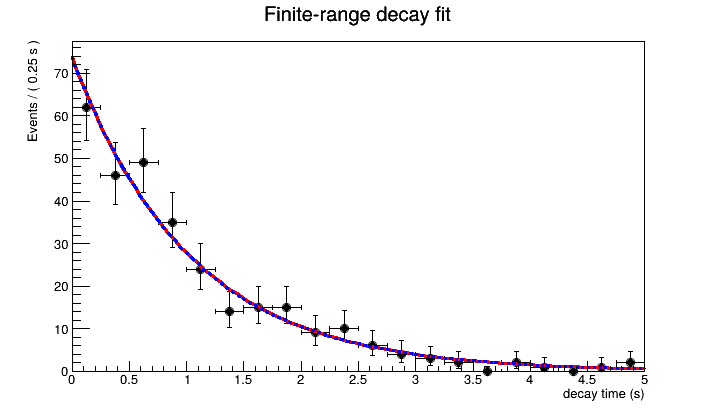

In [16]:
t.setBins(20)
time_bins = ROOT.RooDataHist("time_bins", "same decay times", ROOT.RooArgSet(t), times)
time_binned_result = decay.fitTo(time_bins, RF.Save(), RF.Extended(False), RF.IntegrateBins(1e-6), RF.PrintLevel(-1))
print(f"Binned: tau = {tau.getVal():.4f} +/- {tau.getPropagatedError(time_binned_result):.4f} s; status {time_binned_result.status()}")
decay.plotOn(time_frame, RF.LineColor(ROOT.kBlue), RF.LineStyle(2))
c = ROOT.TCanvas("c_roo_time", "Decay fit", 720, 440)
time_frame.Draw()
c.SaveAs("fit_figures/roofit-decay.png")
display(Image(filename="fit_figures/roofit-decay.png"))

<details><summary>ROOT C++ 对应代码</summary>

```cpp
t.setBins(20);
RooDataHist time_bins("time_bins", "same decay times", RooArgSet(t), *times);
auto time_binned_result = decay.fitTo(time_bins, Save(), Extended(false), IntegrateBins(1e-6), PrintLevel(-1));
std::cout << "Binned: tau = " << tau.getVal() << " +/- " << tau.getPropagatedError(*time_binned_result)
          << " s; status " << time_binned_result->status() << std::endl;
decay.plotOn(time_frame, LineColor(kBlue), LineStyle(2));
c = new TCanvas("c_roo_time", "Decay fit", 720, 440);
time_frame->Draw();
c->SaveAs("fit_figures/roofit-decay.png");
```

</details>

红实线为 unbinned，蓝虚线为 binned。若实际记录有触发门、dead time 或随时间变化的接受度，应先确定观测模型；换拟合接口不能补回缺失的事件。

## 8. 显式 likelihood、profile 与 MINOS

### 8.1 从 fitTo 到 RooMinimizer

`fitTo` 把创建 likelihood 和 minimization 包装在一起。需要查看目标函数或进一步控制算法时，可显式创建 `NLL`（negative log-likelihood）。下面仍拟合第 4 节的同一数据与同一模型，不是新的估计方法。

In [17]:
w.loadSnapshot("unbinned_fit")
nll = model.createNLL(data, RF.Extended())
minimizer = ROOT.RooMinimizer(nll)
minimizer.setPrintLevel(-1)
migrad_status = minimizer.minimize("Minuit2", "Migrad")
hesse_status = minimizer.hesse()
minos_status = minimizer.minos(ROOT.RooArgSet(ns))
manual_result = minimizer.save()
print("Migrad, HESSE, MINOS status:", migrad_status, hesse_status, minos_status)
print(f"ns = {ns.getVal():.3f}; MINOS {ns.getAsymErrorLo():+.3f}, {ns.getAsymErrorHi():+.3f}")

Migrad, HESSE, MINOS status: 0 0 0
ns = 332.218; MINOS -26.457, +27.352


<details><summary>ROOT C++ 对应代码</summary>

```cpp
w.loadSnapshot("unbinned_fit");
auto nll = model->createNLL(*data, Extended());
RooMinimizer minimizer(*nll);
minimizer.setPrintLevel(-1);
int migrad_status = minimizer.minimize("Minuit2", "Migrad");
int hesse_status = minimizer.hesse();
int minos_status = minimizer.minos(RooArgSet(*ns));
auto manual_result = minimizer.save();
std::cout << "Migrad, HESSE, MINOS status: " << migrad_status << ", " << hesse_status << ", " << minos_status << std::endl;
std::cout << "ns = " << ns->getVal() << "; MINOS " << ns->getAsymErrorLo() << ", " << ns->getAsymErrorHi() << std::endl;
```

</details>

### 8.2 固定其他参数与 profile 的区别

直接画 NLL 关于 $N_s$ 的变化时，其他参数保持固定；`createProfile` 则在每一个 $N_s$ 处重新优化其他自由参数。其他参数能补偿部分变化，所以 profile 往往更宽，才对应把 nuisance parameters 一起考虑的 likelihood 区间。

横线 $\Delta(-\log L)=0.5$ 是正则渐近条件下一参数约 $1\sigma$ 的阈值。靠近 $N_s=0$ 等边界、极少事件或多重极小值时，不能自动把交点解释为精确的 68% 区间，更不能把 $N_s/\sigma_{N_s}$ 一律当作发现显著性。

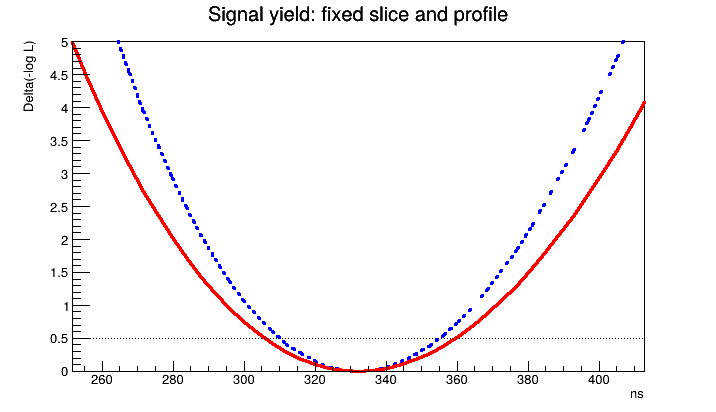

In [18]:
scan = ns.frame(RF.Range(ns.getVal()-3*ns.getError(), ns.getVal()+3*ns.getError()),
                RF.Title("Signal yield: fixed slice and profile"), RF.Bins(40))
nll.plotOn(scan, RF.ShiftToZero(), RF.LineColor(ROOT.kBlue), RF.LineStyle(2))
profile = nll.createProfile(ROOT.RooArgSet(ns))
profile.plotOn(scan, RF.ShiftToZero(), RF.LineColor(ROOT.kRed))
scan.SetMinimum(0)
scan.SetMaximum(5)
scan.GetYaxis().SetTitle("Delta(-log L)")
c = ROOT.TCanvas("c_roo_profile", "Profile likelihood", 720, 440)
scan.Draw()
half_profile = ROOT.TLine(scan.GetXaxis().GetXmin(), 0.5, scan.GetXaxis().GetXmax(), 0.5)
half_profile.SetLineStyle(3)
half_profile.Draw()
w.loadSnapshot("unbinned_fit")
c.SaveAs("fit_figures/roofit-profile.png")
display(Image(filename="fit_figures/roofit-profile.png"))

<details><summary>ROOT C++ 对应代码</summary>

```cpp
auto scan = ns->frame(Range(ns->getVal()-3*ns->getError(), ns->getVal()+3*ns->getError()),
                      Title("Signal yield: fixed slice and profile"), Bins(40));
nll->plotOn(scan, ShiftToZero(), LineColor(kBlue), LineStyle(2));
auto profile = nll->createProfile(RooArgSet(*ns));
profile->plotOn(scan, ShiftToZero(), LineColor(kRed));
scan->SetMinimum(0);
scan->SetMaximum(5);
scan->GetYaxis()->SetTitle("Delta(-log L)");
c = new TCanvas("c_roo_profile", "Profile likelihood", 720, 440);
scan->Draw();
auto half_profile = new TLine(scan->GetXaxis()->GetXmin(), 0.5, scan->GetXaxis()->GetXmax(), 0.5);
half_profile->SetLineStyle(3);
half_profile->Draw();
w.loadSnapshot("unbinned_fit");
c->SaveAs("fit_figures/roofit-profile.png");
```

</details>

红实线为 profile，蓝虚线为固定其余参数的 NLL 切片。Profile 计算会改变模型参数，因此画图后恢复了已保存的拟合状态。

## 9. 多维模型与 simultaneous fit

### 9.1 两个独立观测量的乘积

若在给定参数后 $u$ 与 $v$ 独立，则联合 PDF 为 $p(u,v)=p(u)p(v)$。`PROD` 创建 `RooProdPdf`。下面给一个二维 toy 分布，说明乘积不是把两个组分在同一横轴上相加。

Generated 2D events = 10000


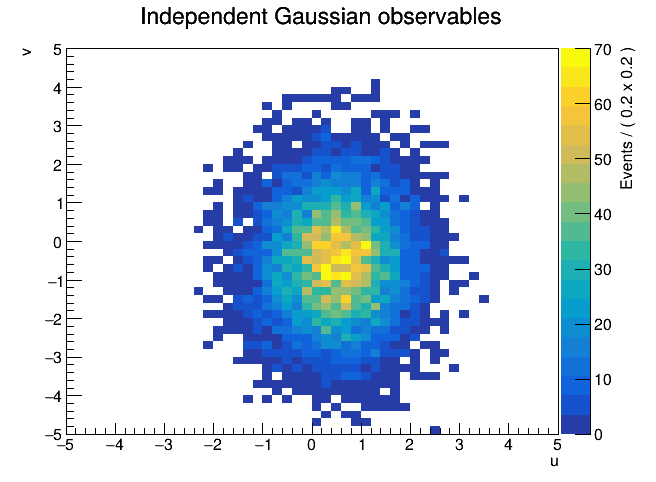

In [19]:
w2 = ROOT.RooWorkspace("w2", "two observables")
w2.factory("Gaussian::gu(u[-5,5],mu_u[0.5],s_u[0.8,0.1,3])")
w2.factory("Gaussian::gv(v[-5,5],mu_v[-0.5],s_v[1.3,0.1,3])")
w2.var("s_u").setConstant(True)
w2.var("s_v").setConstant(True)
w2.factory("PROD::joint(gu,gv)")
uv_data = w2.pdf("joint").generate(ROOT.RooArgSet(w2.var("u"), w2.var("v")), 10000)
h2 = uv_data.createHistogram("uv", w2.var("u"), RF.Binning(50), RF.YVar(w2.var("v"), RF.Binning(50)))
c = ROOT.TCanvas("c_roo_2d", "Independent observables", 660, 510)
c.SetRightMargin(0.15)
h2.SetTitle("Independent Gaussian observables;u;v")
h2.Draw("COLZ")
print("Generated 2D events =", uv_data.numEntries())
c.SaveAs("fit_figures/roofit-two-observables.png")
display(Image(filename="fit_figures/roofit-two-observables.png"))

<details><summary>ROOT C++ 对应代码</summary>

```cpp
RooWorkspace w2("w2", "two observables");
w2.factory("Gaussian::gu(u[-5,5],mu_u[0.5],s_u[0.8,0.1,3])");
w2.factory("Gaussian::gv(v[-5,5],mu_v[-0.5],s_v[1.3,0.1,3])");
w2.var("s_u")->setConstant(true);
w2.var("s_v")->setConstant(true);
w2.factory("PROD::joint(gu,gv)");
auto uv_data = w2.pdf("joint")->generate(RooArgSet(*w2.var("u"), *w2.var("v")), 10000);
auto h2 = uv_data->createHistogram("uv", *w2.var("u"), Binning(50), YVar(*w2.var("v"), Binning(50)));
c = new TCanvas("c_roo_2d", "Independent observables", 660, 510);
c->SetRightMargin(0.15);
h2->SetTitle("Independent Gaussian observables;u;v");
h2->Draw("COLZ");
std::cout << "Generated 2D events = " << uv_data->numEntries() << std::endl;
c->SaveAs("fit_figures/roofit-two-observables.png");
```

</details>

独立假设要由物理或数据支持。相关量一般需要 $p(u\mid v)p(v)$，例如让 Gaussian 的均值依赖 $v$。`expr` / `RooFormulaVar` 可建立这种参数关系；factory 中小写 `expr` 创建普通函数，大写 `EXPR` 创建归一化 PDF，不能互换。更复杂的响应还可用卷积描述，例子见 [RooFit 官方教程目录](https://root.cern.ch/doc/master/group__tutorial__roofit.html)。

### 9.2 两组数据共享一个峰位

假设两台已刻度探测器 A、B 观测同一条谱线，峰位相同但 Gaussian 宽度不同。分别测得 300 和 500 个信号事件；这个示例不含本底，目的是看懂 shared parameter 和 category。

`RooCategory` 标记数据来自哪一组，`RooSimultaneous` 把各组的 PDF 对应到类别。总 likelihood 为 $L_A(\mu,\sigma_A)L_B(\mu,\sigma_B)$，不是把两条谱相加后假设一个共同分辨。

In [20]:
z = ROOT.RooRealVar("z", "energy offset", -5, 5, "keV")
shared_mean = ROOT.RooRealVar("shared_mean", "shared peak position", 0.4, -2, 2)
sigma_a = ROOT.RooRealVar("sigma_a", "resolution A", 0.7, 0.1, 3)
sigma_b = ROOT.RooRealVar("sigma_b", "resolution B", 1.2, 0.1, 3)
pdf_a = ROOT.RooGaussian("pdf_a", "detector A", z, shared_mean, sigma_a)
pdf_b = ROOT.RooGaussian("pdf_b", "detector B", z, shared_mean, sigma_b)
data_a = pdf_a.generate(ROOT.RooArgSet(z), 300)
data_b = pdf_b.generate(ROOT.RooArgSet(z), 500)
channel = ROOT.RooCategory("channel", "detector")
channel.defineType("A")
channel.defineType("B")
combined = ROOT.RooDataSet("combined", "A and B", ROOT.RooArgSet(z), RF.Index(channel), RF.Import("A", data_a))
tagged_b = ROOT.RooDataSet("tagged_b", "B events", ROOT.RooArgSet(z), RF.Index(channel), RF.Import("B", data_b))
combined.append(tagged_b)

<details><summary>ROOT C++ 对应代码</summary>

```cpp
RooRealVar z("z", "energy offset", -5, 5, "keV");
RooRealVar shared_mean("shared_mean", "shared peak position", 0.4, -2, 2);
RooRealVar sigma_a("sigma_a", "resolution A", 0.7, 0.1, 3);
RooRealVar sigma_b("sigma_b", "resolution B", 1.2, 0.1, 3);
RooGaussian pdf_a("pdf_a", "detector A", z, shared_mean, sigma_a);
RooGaussian pdf_b("pdf_b", "detector B", z, shared_mean, sigma_b);
auto data_a = pdf_a.generate(RooArgSet(z), 300);
auto data_b = pdf_b.generate(RooArgSet(z), 500);
RooCategory channel("channel", "detector");
channel.defineType("A");
channel.defineType("B");
RooDataSet combined("combined", "A and B", RooArgSet(z), Index(channel), Import("A", *data_a));
RooDataSet tagged_b("tagged_b", "B events", RooArgSet(z), Index(channel), Import("B", *data_b));
combined.append(tagged_b);
```

</details>

In [21]:
sim = ROOT.RooSimultaneous("sim", "shared mean fit", channel)
sim.addPdf(pdf_a, "A")
sim.addPdf(pdf_b, "B")
shared_mean.setVal(0)
sim_result = sim.fitTo(combined, RF.Save(), RF.Extended(False), RF.PrintLevel(-1))
print("Simultaneous status =", sim_result.status(), "covQual =", sim_result.covQual())
for par in (shared_mean, sigma_a, sigma_b):
    print(f"{par.GetName()} = {par.getVal():.4f} +/- {par.getError():.4f} keV")

Simultaneous status = 0 covQual = 3
shared_mean = 0.4241 +/- 0.0304 keV
sigma_a = 0.6580 +/- 0.0269 keV
sigma_b = 1.1354 +/- 0.0360 keV


<details><summary>ROOT C++ 对应代码</summary>

```cpp
RooSimultaneous sim("sim", "shared mean fit", channel);
sim.addPdf(pdf_a, "A");
sim.addPdf(pdf_b, "B");
shared_mean.setVal(0);
auto sim_result = sim.fitTo(combined, Save(), Extended(false), PrintLevel(-1));
std::cout << "Simultaneous status = " << sim_result->status() << " covQual = " << sim_result->covQual() << std::endl;
for (auto par : {&shared_mean, &sigma_a, &sigma_b})
    std::cout << par->GetName() << " = " << par->getVal() << " +/- " << par->getError() << " keV" << std::endl;
```

</details>

分别画出各组自己的数据和拟合 PDF，两个 PDF 引用的是同一个 `shared_mean` 对象。这样读图即可确认共同峰位并没有强迫两组峰宽相同。

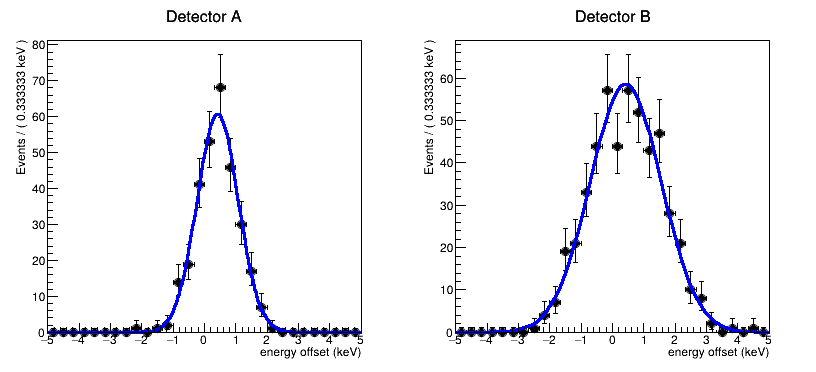

In [22]:
frame_a = z.frame(RF.Title("Detector A"))
frame_b = z.frame(RF.Title("Detector B"))
data_a.plotOn(frame_a, RF.Binning(30))
pdf_a.plotOn(frame_a)
data_b.plotOn(frame_b, RF.Binning(30))
pdf_b.plotOn(frame_b)
c = ROOT.TCanvas("c_roo_sim", "Shared peak position", 820, 400)
c.Divide(2, 1)
c.cd(1)
frame_a.Draw()
c.cd(2)
frame_b.Draw()
c.SaveAs("fit_figures/roofit-simultaneous.png")
display(Image(filename="fit_figures/roofit-simultaneous.png"))

<details><summary>ROOT C++ 对应代码</summary>

```cpp
auto frame_a = z.frame(Title("Detector A"));
auto frame_b = z.frame(Title("Detector B"));
data_a->plotOn(frame_a, Binning(30));
pdf_a.plotOn(frame_a);
data_b->plotOn(frame_b, Binning(30));
pdf_b.plotOn(frame_b);
c = new TCanvas("c_roo_sim", "Shared peak position", 820, 400);
c->Divide(2, 1);
c->cd(1);
frame_a->Draw();
c->cd(2);
frame_b->Draw();
c->SaveAs("fit_figures/roofit-simultaneous.png");
```

</details>

如果两台仪器有未知刻度偏移，就不能直接假设峰位严格相同，应把偏移作为模型中的量处理。若有独立标定测量，也可通过 constraint 项引入；不能把当前拟合本身给出的值又当作独立约束使用。更一般的 category 绘图和建模见 [rf501](https://root.cern.ch/doc/master/rf501__simultaneouspdf_8py.html)。

## 10. 用 toy experiments 验证参数误差

一张谱上的 residual 用来找模型与数据的局部不符；多次独立 toy experiments 则可以检验估计量的偏差和误差尺度。两者不应混称为同一种 pull 检验。

重复 Gaussian 测量，固定每次 100 个事件，生成真值为 $\mu_0=0.4$、$\sigma_0=0.7$，定义

$$\operatorname{pull}(\hat\mu)=\frac{\hat\mu-\mu_0}{\widehat{\sigma}_{\hat\mu}}.$$

如果估计没有明显偏差且误差描述合适，pull 均值应接近 0，宽度接近 1。有限次实验也有涨落；这不是要求把图调到恰好 0 和 1。下面显式统计拟合失败次数，不将失败样本悄悄忽略。

In [23]:
ROOT.RooRandom.randomGenerator().SetSeed(20260911)
toy_pull = ROOT.TH1D("toy_pull", ";pull of mean;experiments", 30, -5, 5)
failed = 0
sum_pull = 0.0
sum_pull2 = 0.0
for i in range(200):
    mean.setVal(0.4)
    sigma.setVal(0.7)
    toy = gauss.generate(obs, 100)
    mean.setVal(0)
    sigma.setVal(1)
    rt = gauss.fitTo(toy, RF.Save(), RF.PrintLevel(-1))
    if rt.status() != 0 or rt.covQual() != 3 or mean.getError() <= 0:
        failed += 1
        continue
    p = (mean.getVal()-0.4)/mean.getError()
    toy_pull.Fill(p)
    sum_pull += p
    sum_pull2 += p*p

<details><summary>ROOT C++ 对应代码</summary>

```cpp
RooRandom::randomGenerator()->SetSeed(20260911);
auto toy_pull = new TH1D("toy_pull", ";pull of mean;experiments", 30, -5, 5);
int failed = 0;
double sum_pull = 0, sum_pull2 = 0;
for (int i = 0; i < 200; ++i) {
    mean.setVal(0.4);
    sigma.setVal(0.7);
    auto toy = gauss.generate(obs, 100);
    mean.setVal(0);
    sigma.setVal(1);
    auto rt = gauss.fitTo(*toy, Save(), PrintLevel(-1));
    if (rt->status() != 0 || rt->covQual() != 3 || mean.getError() <= 0) {
        ++failed;
        delete toy;
        continue;
    }
    double p = (mean.getVal()-0.4)/mean.getError();
    toy_pull->Fill(p);
    sum_pull += p;
    sum_pull2 += p*p;
    delete toy;
}
```

</details>

Attempted = 200; successful = 200; failed = 0
Pull mean = -0.048; sample SD = 0.996
Outside displayed range = 0.0


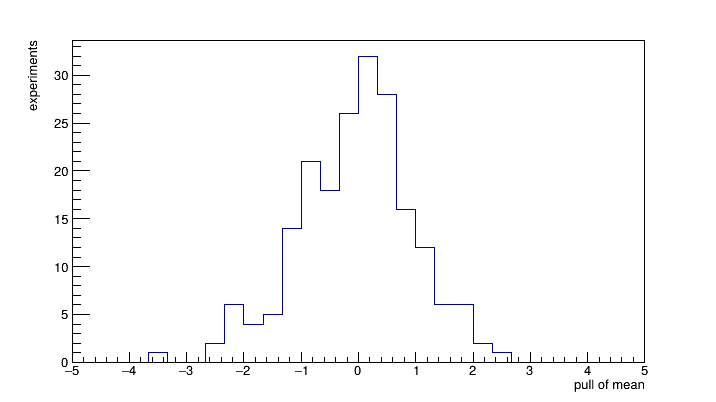

In [24]:
accepted = 200-failed
pull_mean = sum_pull/accepted
pull_sd = math.sqrt((sum_pull2-accepted*pull_mean**2)/(accepted-1))
print(f"Attempted = 200; successful = {accepted}; failed = {failed}")
print(f"Pull mean = {pull_mean:.3f}; sample SD = {pull_sd:.3f}")
print("Outside displayed range =", toy_pull.GetBinContent(0)+toy_pull.GetBinContent(31))
c = ROOT.TCanvas("c_roo_toys", "Parameter pull study", 720, 430)
toy_pull.Draw("HIST")
c.SaveAs("fit_figures/roofit-toy-pulls.png")
display(Image(filename="fit_figures/roofit-toy-pulls.png"))

<details><summary>ROOT C++ 对应代码</summary>

```cpp
int accepted = 200-failed;
double pull_mean = sum_pull/accepted;
double pull_sd = std::sqrt((sum_pull2-accepted*pull_mean*pull_mean)/(accepted-1));
std::cout << "Attempted = 200; successful = " << accepted << "; failed = " << failed << std::endl;
std::cout << "Pull mean = " << pull_mean << "; sample SD = " << pull_sd << std::endl;
std::cout << "Outside displayed range = " << toy_pull->GetBinContent(0)+toy_pull->GetBinContent(31) << std::endl;
c = new TCanvas("c_roo_toys", "Parameter pull study", 720, 430);
toy_pull->Draw("HIST");
c->SaveAs("fit_figures/roofit-toy-pulls.png");
```

</details>

这里检验的是“生成模型与拟合模型相同”时的统计性质，不能证明真实实验没有本底误建模、刻度偏移或效率效应。若研究这些影响，应明确改变生成模型而保留分析模型，再报告这种模型失配造成的偏差。大规模自动研究可用 [RooMCStudy / rf801](https://root.cern.ch/doc/master/rf801__mcstudy_8py.html)。

## 11. 保存、恢复和继续分析

把模型、数据、snapshot 和拟合结果放在一起，可以在另一会话中恢复分析。`import` 会复制对象及其依赖到 workspace；Python 的 `import` 是保留字，所以用 `getattr(w,"import")` 调用这个方法。

下面使用独立教程输出文件 `roofit_example.root`，再次运行会更新它。恢复后要通过 workspace 取得其内部对象，而不是继续使用原会话中的同名变量。

In [25]:
w.loadSnapshot("unbinned_fit")
getattr(w, "import")(data)
getattr(w, "import")(result, "fit_result")
w.writeToFile("roofit_example.root")
saved_file = ROOT.TFile.Open("roofit_example.root")
saved_w = saved_file.Get("w")
saved_w.loadSnapshot("unbinned_fit")
print("Restored events =", saved_w.data("spectrum_data").numEntries())
print(f"Restored ns = {saved_w.var('ns').getVal():.4f}")
saved_file.Close()

Restored events = 1045
Restored ns = 332.2718


<details><summary>ROOT C++ 对应代码</summary>

```cpp
w.loadSnapshot("unbinned_fit");
w.import(*data);
w.import(*result, "fit_result");
w.writeToFile("roofit_example.root");
TFile saved_file("roofit_example.root");
auto saved_w = static_cast<RooWorkspace*>(saved_file.Get("w"));
saved_w->loadSnapshot("unbinned_fit");
std::cout << "Restored events = " << saved_w->data("spectrum_data")->numEntries() << std::endl;
std::cout << "Restored ns = " << saved_w->var("ns")->getVal() << std::endl;
saved_file.Close();
```

</details>

最后回到分析问题本身：观测量与接受范围是否定义清楚，数据是否是原始计数或带权数据，模型是否包含需要的组分，参数误差是否包含相关性。RooFit 帮助组织这些关系，但不会替代对实验过程的判断。

## 资料与文件

- [下载本教程 notebook](RooFit%20mini%20tutorial.ipynb) · [ROOT C++ 完整宏](RooFit_Tutorial.C)。运行宏使用 `root -l -b -q RooFit_Tutorial.C`。
- L. Moneta, [*Fitting and Parameter Estimation*](https://twiki.cern.ch/twiki/pub/Main/ROOTRioTutorial/ROOT_Rio2015_Fitting.pdf), ROOT Tutorial at UERJ, Rio de Janeiro (2015), pp. 39–77.
- W. Verkerke and D. Kirkby, “The RooFit toolkit for data modeling,” *eConf* C0303241, MOLT007 (2003), [arXiv:physics/0306116](https://arxiv.org/abs/physics/0306116).
- ROOT Collaboration, [*RooFit tutorials*](https://root.cern.ch/doc/master/group__tutorial__roofit.html), especially rf101 (basics), rf109 (residual), rf202 (extended likelihood), rf501 (simultaneous fit), rf614 (bin integration), rf801 (toy studies).
- ROOT Collaboration, [RooAbsPdf::fitTo](https://root.cern.ch/doc/master/classRooAbsPdf.html)、[RooAbsReal::getPropagatedError](https://root.cern.ch/doc/master/classRooAbsReal.html)、[RooWorkspace](https://root.cern.ch/doc/master/classRooWorkspace.html), reference documentation.

本教程在 ROOT 6.40.02 中执行验证。代码采用显式 `RooFit` 选项，便于对照 C++；新版 PyROOT 也支持 `Save=True`、`PrintLevel=-1` 等 keyword arguments。关于基础接口的完整例子见 [rf101](https://root.cern.ch/doc/master/rf101__basics_8py.html)。